## Centrality Depencence of Eloss and $p_T$ broadening for Charmonia & Bottomonia

### Import & setup

In [1]:
# ================================
# eLoss + broadening notebook (pub styling)
# ================================
import sys, os, math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
import torch
from matplotlib.lines import Line2D

sys.path.append("../eloss_code")

# --- imports & knobs ---
from particle  import Particle, PPSpectrumParams
from glauber   import SystemSpec, OpticalGlauber
from coupling  import alpha_s_provider
import quenching_fast as QF

# global floors
F1_FLOOR = 1e-16
F2_FLOOR = 1e-12   # for kinematic edge protection
ZC_EPS   = 1e-12

# energies, σ_nn, system
roots5, roots8   = 5023.0, 8160.0
sigma_nn_5, sigma_nn_8 = 67.6, 71.0
A = 208
device = "cuda" if (QF._HAS_TORCH and torch.cuda.is_available()) else "cpu"

# particles
P_charmonia  = Particle(family="charmonia",  state="avg")
P_bottomonia = Particle(family="bottomonia", state="avg")

# y and pT grids for raw curves
y_grid  = np.linspace(-5.0, 5.0, 512)
pT_grid = np.linspace(0.0, 20.0, 512)

# α_s (constant AP choice)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.5)
alpha_s   = alpha_cst

# Glauber for L_eff
gl5 = OpticalGlauber(SystemSpec("pA", roots5, A=A, sigma_nn_mb=sigma_nn_5))
gl8 = OpticalGlauber(SystemSpec("pA", roots8, A=A, sigma_nn_mb=sigma_nn_8))
Lmb_5 = gl5.leff_minbias_pA()
Lmb_8 = gl8.leff_minbias_pA()

# centrality bins → labels and colors
# cent_bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
# cent_labels = [f"{a}-{b}%" for (a,b) in cent_bins]
# tags_order = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
# colors = {
#     "0-20%":  "C0",
#     "20-40%": "C1",
#     "40-60%": "C2",
#     "60-80%": "C3",
#     "80-100%":"C4",
# }

## From here https://arxiv.org/pdf/1304.0901
cent_bins = [(0,20),(20,40),(40,60),(60,100)]
cent_labels = [f"{a}-{b}%" for (a,b) in cent_bins]
tags_order = ["0-20%", "20-40%", "40-60%", "60-100%"]
colors = {
    "0-20%":  "C0",
    "20-40%": "C1",
    "40-60%": "C2",
    "60-80%": "C3",
}

Leff_5 = gl5.leff_bins_pA(cent_bins, method="optical")
Leff_8 = gl8.leff_bins_pA(cent_bins, method="optical")

print("Leff mb:", Lmb_5, " , ", Lmb_8)
print("Leff 5 TeV pPb: ", Leff_5)
print("Leff 8 TeV pPb: ", Leff_8)

# base quench params (central qhat0)
QP5_base = QF.QuenchParams(
    qhat0        = 0.075,
    lp_fm        = 1.5,
    LA_fm        = Lmb_5,
    LB_fm        = Lmb_5,
    lambdaQCD    = 0.25,
    roots_GeV    = roots5,
    alpha_of_mu  = alpha_cst,
    alpha_scale  = "mT",
    use_hard_cronin = True,
    mapping      = "exp",
    device       = device,
)
QP8_base = replace(QP5_base,
                   roots_GeV = roots8,
                   LA_fm     = Lmb_8,
                   LB_fm     = Lmb_8)

## Three rapidity window to compute R_pA vs pT and R_pA vs Centrality
RAPIDITY_WINDOWS   = [(-4.46,-2.96), (-1.37,0.43), (2.03,3.53)]

# qhat0 band (center 0.075) -- to get error band in eloss
Q0_PAIR = (0.05, 0.09) 
# Other parameter for pp

def _qp_device(qp):
    """
    Use qp.device when possible. If qp.device=='cuda' but CUDA isn't available,
    fall back to CPU.
    """
    dev_str = getattr(qp, "device", None)
    if dev_str is None:
        dev_str = "cuda" if (QF._HAS_TORCH and torch.cuda.is_available()) else "cpu"
    if dev_str == "cuda" and not torch.cuda.is_available():
        dev_str = "cpu"
    return torch.device(dev_str)


## Make “scaled p0” particles (for broadening band)
from copy import deepcopy

def particle_with_scaled_p0(P: Particle, scale: float) -> Particle:
    """
    Return a new Particle with pp.p0 → scale * p0 (m,n unchanged).
    All other attributes (family, state, mass) are copied.
    """
    pp = P.pp
    new_pp = PPSpectrumParams(p0=pp.p0 * scale, m=pp.m, n=pp.n)
    return Particle(
        family=P.family,
        state=P.state,
        mass_override_GeV=P.mass_override_GeV,
        pp_params=new_pp,
    )

## min bias
Leff_mb_5 = gl5.leff_minbias_pA()
Leff_mb_8 = gl8.leff_minbias_pA()


print("Leff 5 TeV pPb Min Bias: ", Leff_mb_5)
print("Leff 8 TeV pPb Min Bias: ", Leff_mb_8)

# base quench params (central qhat0)
QP5_base_mb = QF.QuenchParams(
    qhat0        = 0.075,
    lp_fm        = 1.5,
    LA_fm        = Leff_mb_5,
    LB_fm        = Leff_mb_5,
    lambdaQCD    = 0.25,
    roots_GeV    = roots5,
    alpha_of_mu  = alpha_cst,
    alpha_scale  = "mT",
    use_hard_cronin = True,
    mapping      = "exp",
    device       = device,
)
QP8_base_mb = replace(QP5_base_mb,
                      roots_GeV=roots8,
                      LA_fm=Leff_mb_8,
                      LB_fm=Leff_mb_8)

[OpticalGlauber] Target A=208, d=0.549 fm, σ_nn=67.60 mb
[OpticalGlauber] ∫ d²s T_A(s) ≈ 208.483  (should be ~A=208)
[OpticalGlauber] ∫ d²s T_d(s) ≈ 1.9972  (should be ~2)
[OpticalGlauber] Tabulating overlaps T_AA(b), T_pA(b), T_dA(b)...
[OpticalGlauber] σ_tot: AA=7724.4 mb, pA=1911.6 mb, dA=2364.6 mb
[OpticalGlauber] Target A=208, d=0.549 fm, σ_nn=71.00 mb
[OpticalGlauber] ∫ d²s T_A(s) ≈ 208.483  (should be ~A=208)
[OpticalGlauber] ∫ d²s T_d(s) ≈ 1.9972  (should be ~2)
[OpticalGlauber] Tabulating overlaps T_AA(b), T_pA(b), T_dA(b)...
[OpticalGlauber] σ_tot: AA=7757.8 mb, pA=1925.9 mb, dA=2381.9 mb
Leff mb: 10.414158247314315  ,  10.414158247314315
Leff 5 TeV pPb:  {'0-20%': 13.342070487739491, '20-40%': 10.916329904911066, '40-60%': 7.875318235779347, '60-100%': 4.111175979143701}
Leff 8 TeV pPb:  {'0-20%': 13.33422721420849, '20-40%': 10.885839100322919, '40-60%': 7.818239382422631, '60-100%': 4.069286283993883}
Leff 5 TeV pPb Min Bias:  10.414158247314315
Leff 8 TeV pPb Min Bias:  1

## Calculation of $R^{eloss}_{pA}$ and $R^{p_T \, broad}_{pA}$ [RAW]

#### pp Parameterization

In [2]:
# ---------- pp parametrisation: F1(pT) * F2(y,pT) ----------

def F1_t(P: Particle, pT_t: torch.Tensor) -> torch.Tensor:
    """
    F1(p_T) = (p0^2 / (p0^2 + p_T^2))^m
    """
    p0, m, _ = P.pp.p0, P.pp.m, P.pp.n
    p0_sq = float(p0) * float(p0)
    return (p0_sq / (p0_sq + pT_t * pT_t))**m

def F2_t(P: Particle,
         y_t: torch.Tensor,
         pT_t: torch.Tensor,
         roots_GeV: float) -> torch.Tensor:
    """
    F2(y,p_T) = [1 - 2 M_T cosh(y) / sqrt(s)]^n, clamped ≥ 0.
    """
    _, _, n = P.pp.p0, P.pp.m, P.pp.n
    M = float(P.M_GeV)
    roots = float(roots_GeV)
    pT_sq = pT_t * pT_t
    mT    = torch.sqrt(pT_sq + M*M)
    arg   = 1.0 - (2.0*mT/roots)*torch.cosh(y_t)
    arg_clamped = torch.clamp(arg, min=1e-30)
    return arg_clamped**n

def F2_t_pt(P: Particle,
            y_val: float,
            pT_t: torch.Tensor,
            roots_GeV: float,
            device=None) -> torch.Tensor:
    if device is None:
        device = pT_t.device
    y_t = torch.full_like(pT_t, float(y_val), device=device)
    return F2_t(P, y_t, pT_t, roots_GeV)

# ---------- x_A with safety clamp ----------

XMIN_SAFE = 1e-12
XMAX_SAFE = 0.99

def xA_scalar(P: Particle, roots_GeV: float, qp, y: float, pT: float) -> float:
    """
    x_A = min( x0(L_A), x_2 ) with
      x_2 = (m_T / sqrt(s)) e^{-y},
      x0(L_A) = ħc / (2 m_p L_A).
    Then clamped to [XMIN_SAFE, XMAX_SAFE].
    """
    M  = float(P.M_GeV)
    mT = math.sqrt(M*M + float(pT)**2)
    x2 = (mT / float(roots_GeV)) * math.exp(-float(y))
    x0 = QF.xA0_from_L(qp.LA_fm)
    xA = min(x0, x2)
    xA = max(XMIN_SAFE, min(XMAX_SAFE, xA))
    return float(xA)

#### Testing and Debugging

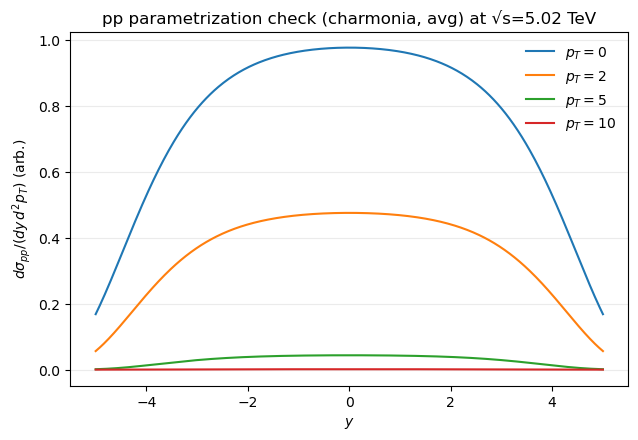

In [3]:
# ================================
# pp sanity plots (FAST, minimal)
# ================================

def dsig_pp_scalar(P, roots, y, pT):
    return float(P.d2sigma_pp(float(y), float(pT), float(roots)))

# choose particle to sanity check:
P_test = P_charmonia   # switch to P_bottomonia if you want

# (1) pp vs y at fixed pT
pT_slices = [0.0, 2.0, 5.0, 10.0]
y_plot = np.linspace(-5.0, 5.0, 501)

plt.figure(figsize=(7.2,4.6))
for pT0 in pT_slices:
    vals = np.array([dsig_pp_scalar(P_test, roots5, y, pT0) for y in y_plot])
    plt.plot(y_plot, vals, label=fr"$p_T={pT0:g}$")
# plt.yscale("log")
plt.xlabel(r"$y$")
plt.ylabel(r"$d\sigma_{pp}/(dy\,d^2p_T)$ (arb.)")
plt.title(f"pp parametrization check ({P_test.family}, {P_test.state}) at √s={roots5/1e3:.3g} TeV")
plt.legend(frameon=False)
plt.grid(True, which="both", axis="y", alpha=0.25)
plt.show()

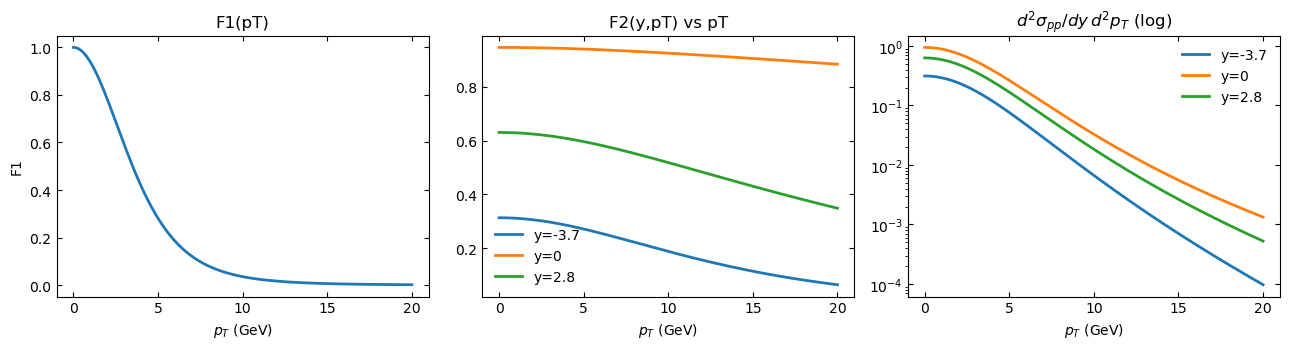

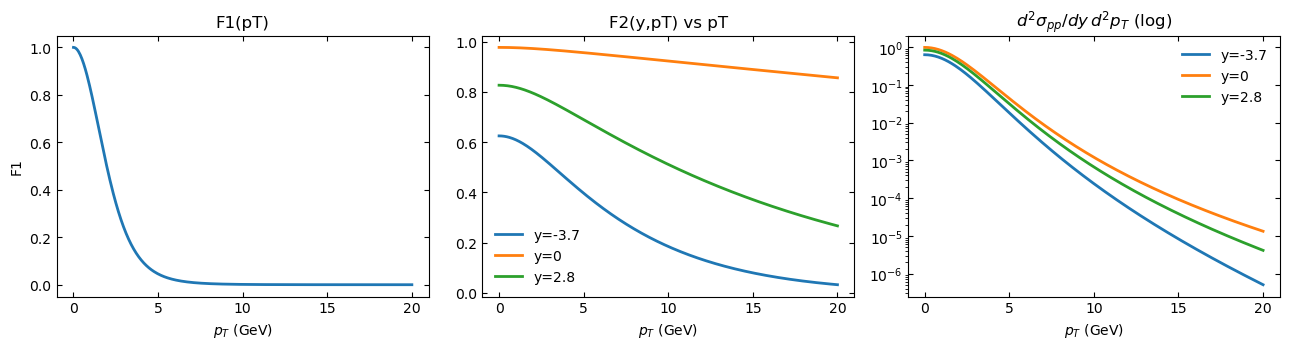

In [4]:
# =========================
# Quick pp sanity plots
# =========================
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_pp_sanity(P, roots_GeV, y_vals=(-3.7,0.0,2.8), pTmax=20.0):
    device = torch.device("cpu")
    pT = torch.linspace(0.0, pTmax, 400, dtype=torch.float64, device=device)
    fig, axs = plt.subplots(1, 3, figsize=(13,3.6))

    # (1) F1(pT)
    axs[0].plot(pT.cpu(), F1_t(P, pT).cpu(), lw=2)
    axs[0].set_title("F1(pT)")
    axs[0].set_xlabel(r"$p_T$ (GeV)")
    axs[0].set_ylabel("F1")

    # (2) F2(y,pT) vs pT for a few y
    for y in y_vals:
        y_t = torch.full_like(pT, float(y))
        axs[1].plot(pT.cpu(), F2_t(P, y_t, pT, roots_GeV).cpu(), lw=2, label=f"y={y:g}")
    axs[1].set_title("F2(y,pT) vs pT")
    axs[1].set_xlabel(r"$p_T$ (GeV)")
    axs[1].legend(frameon=False)

    # (3) full Particle pp cross section slice vs pT for a few y
    pT_np = np.linspace(0.0, pTmax, 200)
    for y in y_vals:
        sig = np.array([P.d2sigma_pp(float(y), float(pt), float(roots_GeV)) for pt in pT_np])
        axs[2].plot(pT_np, sig, lw=2, label=f"y={y:g}")
    axs[2].set_yscale("log")
    axs[2].set_title(r"$d^2\sigma_{pp}/dy\,d^2p_T$ (log)")
    axs[2].set_xlabel(r"$p_T$ (GeV)")
    axs[2].legend(frameon=False)

    for ax in axs:
        ax.tick_params(direction="in", top=True, right=True)
    fig.tight_layout()
    return fig

plot_pp_sanity(P_bottomonia, roots5)
plt.show()

plot_pp_sanity(P_charmonia, roots5)
plt.show()

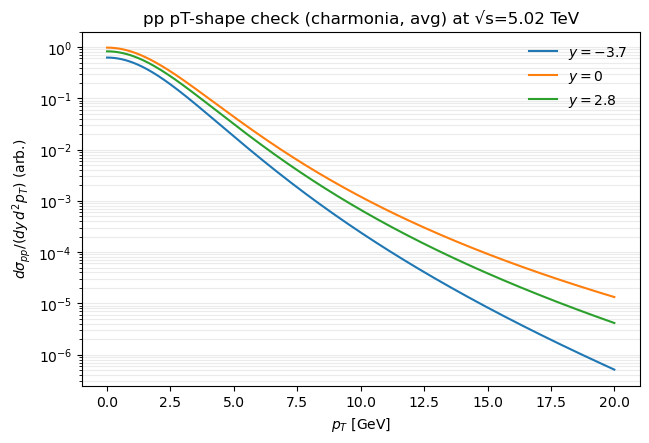

In [5]:
# (2) pp vs pT at fixed y
y_slices = [-3.7, 0.0, 2.8]
pT_plot = np.linspace(0.0, 20.0, 401)

plt.figure(figsize=(7.2,4.6))
for y0 in y_slices:
    vals = np.array([dsig_pp_scalar(P_test, roots5, y0, pT) for pT in pT_plot])
    plt.plot(pT_plot, vals, label=fr"$y={y0:g}$")
plt.yscale("log")
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$d\sigma_{pp}/(dy\,d^2p_T)$ (arb.)")
plt.title(f"pp pT-shape check ({P_test.family}, {P_test.state}) at √s={roots5/1e3:.3g} TeV")
plt.legend(frameon=False)
plt.grid(True, which="both", axis="y", alpha=0.25)
plt.show()

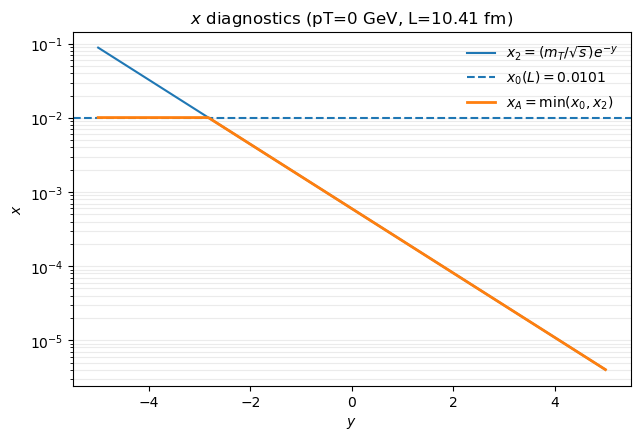

In [6]:
# ================================
# xA diagnostics: x0(L), x2(y,pT), xA=min
# ================================
P_test = P_charmonia
qp_test = QP5_base_mb  # or any qp

pT0 = 0.0
y_plot = np.linspace(-5.0, 5.0, 501)

x0 = QF.xA0_from_L(qp_test.LA_fm)
x2 = np.array([(float(P_test.mT(pT0))/roots5)*np.exp(-y) for y in y_plot])
xA = np.minimum(x0, x2)

plt.figure(figsize=(7.2,4.6))
plt.plot(y_plot, x2, label=r"$x_2=(m_T/\sqrt{s})e^{-y}$")
plt.axhline(x0, ls="--", label=fr"$x_0(L)={x0:.3g}$")
plt.plot(y_plot, xA, lw=2, label=r"$x_A=\min(x_0,x_2)$")
plt.yscale("log")
plt.xlabel(r"$y$")
plt.ylabel(r"$x$")
plt.title(fr"$x$ diagnostics (pT={pT0:g} GeV, L={qp_test.LA_fm:.2f} fm)")
plt.legend(frameon=False)
plt.grid(True, which="both", axis="y", alpha=0.25)
plt.show()

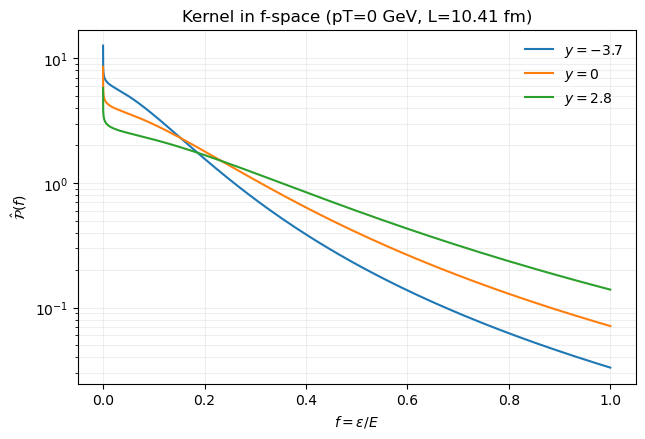

In [7]:
# ================================
# Quenching-weight diagnostics
# ================================
import numpy as np
import torch

P_test = P_charmonia
qp_test = QP5_base_mb
roots = roots5

def phat_vs_f(P, qp, y, pT, f_grid):
    dev = _qp_device(qp)
    mT = float(P.mT(pT))
    xA = xA_scalar(P, roots, qp, y, pT)
    f_t  = torch.tensor(f_grid, dtype=torch.float64, device=dev).clamp_min(QF.Z_FLOOR)
    xA_t = torch.full_like(f_t, xA, dtype=torch.float64)
    with torch.no_grad():
        ph = QF.PhatA_t(f_t, mT, xA_t, qp, pT=pT).detach().cpu().numpy()
    return ph

def phat_integrand_vs_dy(P, qp, y, pT, dy_grid):
    dev = _qp_device(qp)
    mT = float(P.mT(pT))
    xA = xA_scalar(P, roots, qp, y, pT)
    dy_t = torch.tensor(dy_grid, dtype=torch.float64, device=dev)
    z_t  = torch.expm1(dy_t).clamp_min(QF.Z_FLOOR)  # f = e^{dy}-1
    xA_t = torch.full_like(z_t, xA, dtype=torch.float64)
    with torch.no_grad():
        ph = QF.PhatA_t(z_t, mT, xA_t, qp, pT=pT).detach().cpu().numpy()
    return ph

# choose a few points
y_list  = [-3.7, 0.0, 2.8]
pT0     = 0.0
f_grid  = np.logspace(-6, 0, 600)      # f in (1e-6 ... 1)
dy_grid = np.linspace(0.0, np.log(2.0), 600)

plt.figure(figsize=(7.2,4.6))
for y0 in y_list:
    ph = phat_vs_f(P_test, qp_test, y0, pT0, f_grid)
    plt.plot(f_grid, ph, label=fr"$y={y0:g}$")
# plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$f=\varepsilon/E$")
plt.ylabel(r"$\hat{\mathcal{P}}(f)$")
plt.title(fr"Kernel in f-space (pT={pT0:g} GeV, L={qp_test.LA_fm:.2f} fm)")
plt.legend(frameon=False)
plt.grid(True, which="both", alpha=0.2)
plt.show()

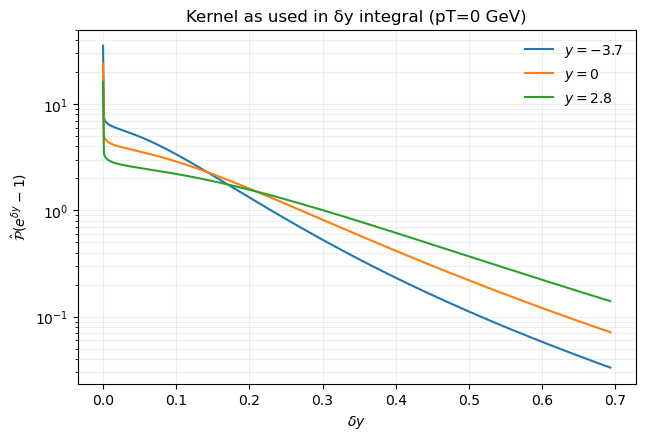

In [8]:
plt.figure(figsize=(7.2,4.6))
for y0 in y_list:
    ph_dy = phat_integrand_vs_dy(P_test, qp_test, y0, pT0, dy_grid)
    plt.plot(dy_grid, ph_dy, label=fr"$y={y0:g}$")
plt.yscale("log")
plt.xlabel(r"$\delta y$")
plt.ylabel(r"$\hat{\mathcal{P}}(e^{\delta y}-1)$")
plt.title(fr"Kernel as used in δy integral (pT={pT0:g} GeV)")
plt.legend(frameon=False)
plt.grid(True, which="both", alpha=0.2)
plt.show()

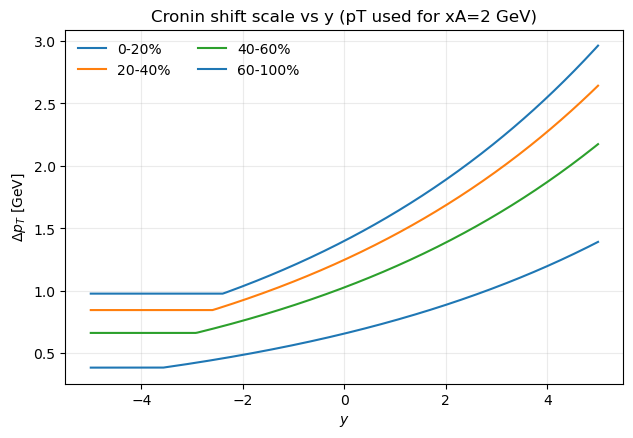

In [9]:
# ================================
# Broadening diagnostics: ΔpT(y) for different L_eff (centralities)
# ================================
P_test = P_charmonia
roots  = roots5
pT_for_xA = 2.0
y_plot = np.linspace(-5.0, 5.0, 301)

# build qp per centrality
qp_by_tag = {}
for tag in tags_order:
    L = Leff_5[tag]  # using 5 TeV pPb
    qp_by_tag[tag] = replace(QP5_base, LA_fm=float(L), LB_fm=float(L))

plt.figure(figsize=(7.2,4.6))
for tag in tags_order:
    qp = qp_by_tag[tag]
    dev = _qp_device(qp)

    dpt_list = []
    for y0 in y_plot:
        xA = xA_scalar(P_test, roots, qp, y0, pT_for_xA)
        xA_t = torch.tensor([xA], dtype=torch.float64, device=dev)
        with torch.no_grad():
            dpt = QF._dpt_from_xL_t(qp, xA_t, qp.LA_fm, hard=qp.use_hard_cronin)[0].item()
        dpt_list.append(dpt)

    plt.plot(y_plot, dpt_list, label=tag, color=colors.get(tag, None))

plt.xlabel(r"$y$")
plt.ylabel(r"$\Delta p_T$ [GeV]")
plt.title(fr"Cronin shift scale vs y (pT used for xA={pT_for_xA:g} GeV)")
plt.legend(frameon=False, ncol=2)
plt.grid(True, alpha=0.25)
plt.show()

dymax = 0.6931471805599453
60-100% L= 4.111175979143701 xA= 0.00013546110388447372 Zc= 491.0912343897843 p0= 0.0
40-60% L= 7.875318235779347 xA= 0.00013546110388447372 Zc= 1.2307575200611653 p0= 0.0
20-40% L= 10.916329904911066 xA= 0.00013546110388447372 Zc= 0.9274648641848295 p0= 0.07253513581517046
0-20% L= 13.342070487739491 xA= 0.00013546110388447372 Zc= 0.9134824845454516 p0= 0.08651751545454844


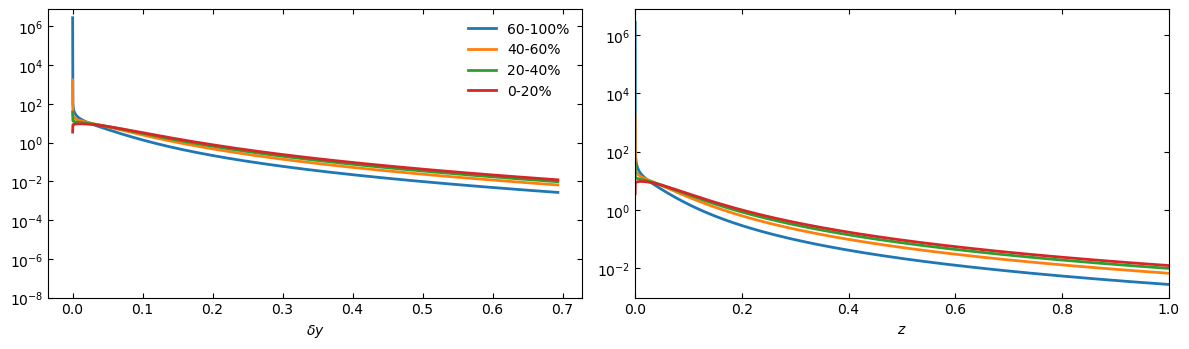

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from dataclasses import replace
import math

# IMPORTANT: make XMIN_SAFE tiny for debugging
XMIN_SAFE = 1e-12

y0  = 2.8     # forward
pT0 = 5.0

L_list = [Leff_5["60-100%"], Leff_5["40-60%"], Leff_5["20-40%"], Leff_5["0-20%"]]
L_tags = ["60-100%", "40-60%", "20-40%", "0-20%"]

device = _qp_device(QP5_base_mb)

M  = float(P_bottomonia.M_GeV)
mT = math.sqrt(M*M + pT0*pT0)

ymax_pt = QF.y_max(roots5, mT)
dym = QF.dymax(y0, ymax_pt)
print("dymax =", dym)

# dy grid (linear is fine for plotting)
dy = torch.linspace(0.0, float(dym), 2000, dtype=torch.float64, device=device)
z  = torch.expm1(dy).clamp_min(QF.Z_FLOOR)

fig, axs = plt.subplots(1, 2, figsize=(12,3.6))

for L, tag in zip(L_list, L_tags):
    qpL = replace(QP5_base_mb, LA_fm=float(L), LB_fm=float(L))

    xA_val = xA_scalar(P_bottomonia, roots5, qpL, y0, pT0)
    xA = torch.full_like(dy, float(xA_val))

    with torch.no_grad():
        ph = QF.PhatA_t(z, mT, xA, qpL, pT=pT0)

    # normalisation check: Zc = ∫ dδy ph
    Zc = float(torch.trapz(ph, dy).item())
    p0 = max(0.0, 1.0 - Zc)
    print(tag, "L=",L, "xA=",xA_val, "Zc=",Zc, "p0=",p0)

    axs[0].plot(dy.cpu().numpy(), ph.cpu().numpy(), lw=2, label=f"{tag}")

    # plot vs z too (helps intuition)
    axs[1].plot(z.cpu().numpy(),  ph.cpu().numpy(), lw=2, label=f"{tag}")

axs[0].set_xlabel(r"$\delta y$")
axs[0].set_yscale("log")
axs[0].set_ylim(1e-8, None)
axs[1].set_xlabel(r"$z$")
axs[1].set_yscale("log")
axs[1].set_xlim(0, 1.0)

for ax in axs:
    ax.tick_params(direction="in", top=True, right=True)
axs[0].legend(frameon=False)
fig.tight_layout()
plt.show()


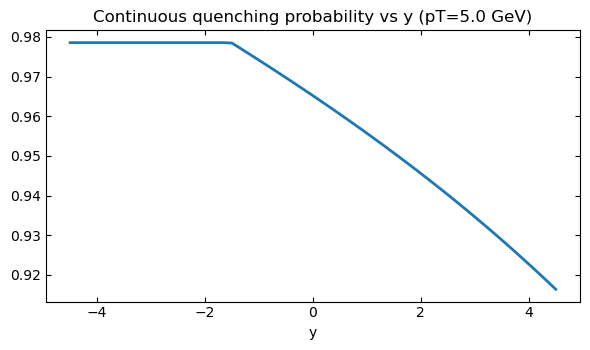

In [11]:
def Zc_of_ypt(P, roots_GeV, qp, y, pT, N=1500):
    device = _qp_device(qp)
    M = float(P.M_GeV)
    mT = math.sqrt(M*M + pT*pT)
    dym = QF.dymax(y, QF.y_max(roots_GeV, mT))
    if dym <= 1e-8:
        return 0.0
    dy = torch.linspace(0.0, float(dym), N, dtype=torch.float64, device=device)
    z  = torch.expm1(dy).clamp_min(QF.Z_FLOOR)
    xA_val = xA_scalar(P, roots_GeV, qp, y, pT)
    xA = torch.full_like(dy, float(xA_val))
    with torch.no_grad():
        ph = QF.PhatA_t(z, mT, xA, qp, pT=pT)
    return float(torch.trapz(ph, dy).item())

# quick curves: Zc(y) at fixed pT
pT_fix = 5.0
y_scan = np.linspace(-4.5, 4.5, 61)
Zc_y  = [Zc_of_ypt(P_bottomonia, roots5, QP5_base_mb, float(y), pT_fix) for y in y_scan]

plt.figure(figsize=(6,3.6))
plt.plot(y_scan, Zc_y, lw=2)
plt.xlabel("y")
plt.tick_params(direction="in", top=True, right=True)
plt.title(f"Continuous quenching probability vs y (pT={pT_fix} GeV)")
plt.tight_layout()
plt.show()


In [12]:
# --- IMPORTANT for comparing to AP Fig. 5 (J/psi) ---
P = Particle(family="charmonia", state="Jpsi")
P.print_summary(roots5)

# Use 5 TeV setup by default
roots_GeV = roots5

# pick a working device
device = "cuda" if (QF._HAS_TORCH and torch.cuda.is_available()) else "cpu"


[Particle] JPsi  M=3.0969 GeV  pp:(p0=4.2, m=3.5, n=19.2), sqrt(s)=5023 GeV


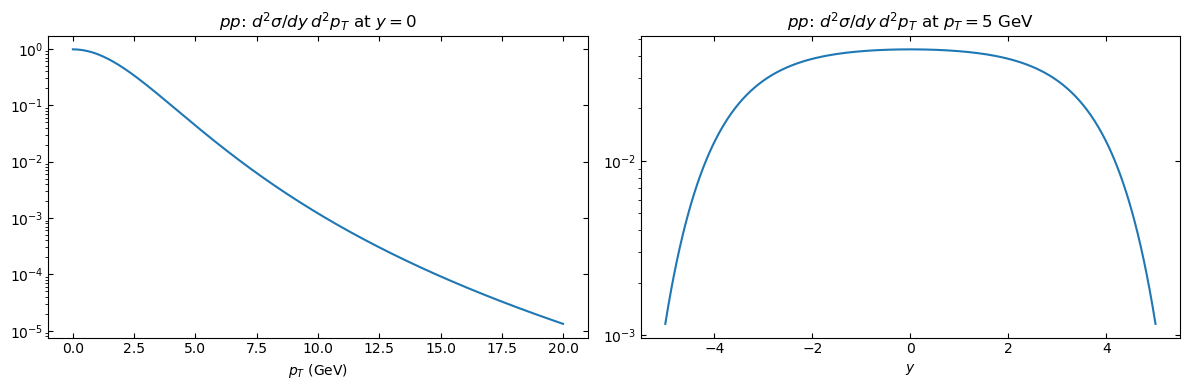

In [13]:
# ---- pp sanity checks ----
pT_test = np.linspace(0.0, 20.0, 400)
y_test  = np.linspace(-5.0, 5.0, 500)

# Full pp (shape only; normalization irrelevant here)
pp_pt_y0 = np.array([P.d2sigma_pp(0.0, pt, roots_GeV) for pt in pT_test])
pp_y_pt5 = np.array([P.d2sigma_pp(y, 5.0, roots_GeV) for y in y_test])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(pT_test, pp_pt_y0)
ax[0].set_title(r"$pp$: $d^2\sigma/dy\,d^2p_T$ at $y=0$")
ax[0].set_xlabel(r"$p_T$ (GeV)")
ax[0].set_yscale("log")
ax[0].tick_params(direction="in", top=True, right=True)

ax[1].plot(y_test, pp_y_pt5)
ax[1].set_title(r"$pp$: $d^2\sigma/dy\,d^2p_T$ at $p_T=5$ GeV")
ax[1].set_xlabel(r"$y$")
ax[1].set_yscale("log")
ax[1].tick_params(direction="in", top=True, right=True)

plt.tight_layout()
plt.show()


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_961207/1967513690.py:3: SyntaxWarning: invalid escape sequence '\h'
  Returns phat(dy) = \hat{P}(z=exp(dy)-1 ; l^2) evaluated along dy_grid


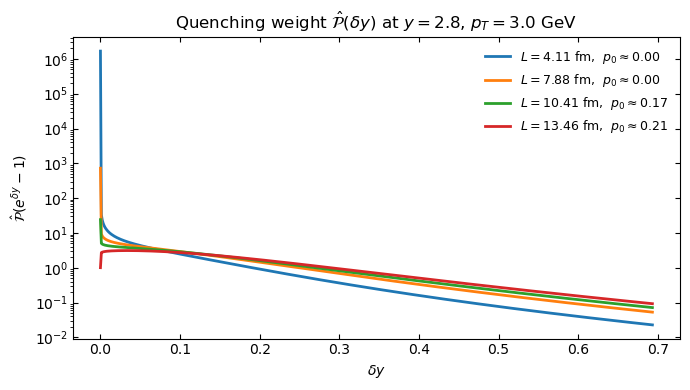

In [14]:
def phat_vs_dy(P, qp, y, pT, roots_GeV, dy_grid):
    """
    Returns phat(dy) = \hat{P}(z=exp(dy)-1 ; l^2) evaluated along dy_grid
    and the estimated Zc and p0.
    """
    dev = _qp_device(qp)
    M  = float(P.M_GeV)
    mT = math.sqrt(M*M + float(pT)**2)
    xA_val = xA_scalar(P, roots_GeV, qp, y, pT)

    with torch.no_grad():
        dy_t = torch.tensor(dy_grid, dtype=torch.float64, device=dev)
        z_t  = torch.expm1(dy_t).clamp_min(QF.Z_FLOOR)
        xA_t = torch.full_like(z_t, float(xA_val))

        ph = QF.PhatA_t(z_t, mT, xA_t, qp, pT=float(pT))
        ph_cpu = ph.detach().cpu().numpy()

    # crude normalization check on the plotted dy_grid (not the real GL integral)
    Zc_est = float(np.trapezoid(ph_cpu, dy_grid))
    p0_est = float(max(0.0, 1.0 - Zc_est))
    return ph_cpu, Zc_est, p0_est

# pick some L values (including your target ~13.46)
L_list = [4.11, 7.88, 10.41, 13.46]   # peripheral -> central-ish
y_fix  = 2.8
pT_fix = 3.0

# choose dy range up to the true dymax for that point
mT_fix = float(P.mT(pT_fix))
dy_max_phys = QF.dymax(y_fix, QF.y_max(roots_GeV, mT_fix))
dy_plot_max = min(dy_max_phys, math.log(2.0))
dy_grid = np.linspace(0.0, dy_plot_max, 600)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for L in L_list:
    qpL = replace(QP5_base_mb, LA_fm=float(L), device=device)
    ph, Zc_est, p0_est = phat_vs_dy(P, qpL, y_fix, pT_fix, roots_GeV, dy_grid)
    ax.plot(dy_grid, ph, lw=2, label=rf"$L={L:.2f}$ fm,  $p_0\approx{p0_est:.2f}$")

ax.set_title(rf"Quenching weight $\hat{{\mathcal{{P}}}}(\delta y)$ at $y={y_fix}$, $p_T={pT_fix}$ GeV")
ax.set_xlabel(r"$\delta y$")
ax.set_ylabel(r"$\hat{\mathcal{P}}(e^{\delta y}-1)$")
ax.set_yscale("log")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

#### $R^{eloss}_{pA}$, $R^{p_T \, broad}_{pA}$ & $R^{p_T \, eloss \times broad}_{pA}$ calculation

In [15]:
# ---------- Coherent energy-loss factor R_pA^loss ----------

def R_pA_eloss(
    P: Particle,
    roots_GeV: float,
    qp,
    y: float,
    pT: float,
    Ny: int | None = None,
) -> float:
    r"""
    Coherent energy-loss factor (Arleo–Peigné).

    Use z = ε/E = exp(δy) - 1 as the natural variable of the quenching weight.
    Then:
      1 - p0 = ∫_0^{zmax} dz  P̂(z)
      R_loss = p0 + ∫_0^{zmax} dz P̂(z) * [1/(1+z)] * [F2(y+ln(1+z),pT)/F2(y,pT)].
    """
    if not QF._HAS_TORCH:
        raise RuntimeError("R_pA_eloss: torch (double precision) required.")

    device = _qp_device(qp)
    M   = float(P.M_GeV)
    pT0 = float(pT)
    mT  = math.sqrt(M*M + pT0*pT0)

    # δy_max (paper uses min(ln2, y_max - y))
    y_max_pt = QF.y_max(roots_GeV, mT)
    dym      = QF.dymax(+y, y_max_pt)
    if dym <= QF.DY_EPS:
        return 1.0

    if Ny is None:
        Ny = QF._Ny_from_dymax(dym)

    # z_max = exp(δy_max) - 1
    zmax = math.expm1(dym)
    if zmax <= QF.Z_FLOOR:
        return 1.0

    xA_val = xA_scalar(P, roots_GeV, qp, y, pT0)

    with torch.no_grad():
        xA    = torch.tensor([xA_val], dtype=torch.float64, device=device)
        y0_t  = torch.tensor([y],     dtype=torch.float64, device=device)
        pT0_t = torch.tensor([pT0],   dtype=torch.float64, device=device)

        F2_den_t = F2_t(P, y0_t, pT0_t, roots_GeV)[0]
        if F2_den_t <= F2_FLOOR:
            return 1.0

        mapping = getattr(qp, "mapping", "exp")

        if mapping == "exp":
            # integrate in log-z: u = ln z, z = e^u
            umin = -30.0
            umax = math.log(max(zmax, 1e-300))
            u, wu = QF._gl_nodes_torch(umin, umax, Ny, device)

            z   = torch.exp(u).clamp_min(QF.Z_FLOOR)
            ph  = QF.PhatA_t(z, mT, xA.expand_as(z), qp, pT=pT0)
            if (ph <= 0).all():
                return 1.0

            # δy = ln(1+z)
            dy     = torch.log1p(z)
            yshift = y + dy

            F2_num = F2_t(P, yshift, pT0_t.expand_as(yshift), roots_GeV)
            ratio  = F2_num / F2_den_t
            ratio  = torch.where(torch.isfinite(ratio) & (ratio >= 0.0), ratio, torch.zeros_like(ratio))

            jac_z = torch.exp(u)         # dz/du
            inv1pz = 1.0 / (1.0 + z)     # from dδy = dz/(1+z) in the continuous term

            # continuous contribution: ∫ dz ph * (1/(1+z)) * ratio
            val = torch.sum(wu * jac_z * ph * inv1pz * ratio)

            # normalization for p0: 1 - p0 = ∫ dz ph
            Zc  = torch.sum(wu * jac_z * ph)

        else:
            # linear z integration
            z, wz = QF._gl_nodes_torch(0.0, float(zmax), Ny, device)
            z = z.clamp_min(QF.Z_FLOOR)

            ph  = QF.PhatA_t(z, mT, xA.expand_as(z), qp, pT=pT0)
            if (ph <= 0).all():
                return 1.0

            dy     = torch.log1p(z)
            yshift = y + dy

            F2_num = F2_t(P, yshift, pT0_t.expand_as(yshift), roots_GeV)
            ratio  = F2_num / F2_den_t
            ratio  = torch.where(torch.isfinite(ratio) & (ratio >= 0.0), ratio, torch.zeros_like(ratio))

            inv1pz = 1.0 / (1.0 + z)

            val = torch.sum(wz * ph * inv1pz * ratio)
            Zc  = torch.sum(wz * ph)

        # p0 from correct normalization in z
        Zc = torch.clamp(Zc, min=0.0, max=1.0)
        p0 = torch.clamp(1.0 - Zc, 0.0, 1.0)

        R_loss = p0 + val
        return float(R_loss.item())



# ---------- pT broadening factor R_pA^broad ----------

def R_pA_broad(
    P: Particle,
    roots_GeV: float,
    qp,
    y: float,
    pT: float,
    Nphi: int = 128,
    Nk: int = 32,
) -> float:
    r"""
    Cronin/broadening factor.

    Two supported implementations (select via qp.broad_model / qp.broadening_model):
      - "ring" (default): Arleo-style *fixed-magnitude* broadening with φ-average only
            pT' = |pT - ΔpT| in 2D with |ΔpT| = sqrt(<k^2>)
            R = ⟨ σ_pp(y,pT') / σ_pp(y,pT) ⟩_φ

      - "gauss": full 2D Gaussian smearing
            ∫ d^2k [1/(πΔ)] exp(-k^2/Δ) σ_pp(y,|pT-k|) / σ_pp(y,pT),
            with Δ = <k^2>.

    Notes:
      - "ring" reproduces the strong low-pT depletion/peak structure seen in
        Arleo–Peigné-type implementations.
      - Keep signature unchanged; Nk is ignored in "ring".
    """
    if not QF._HAS_TORCH:
        raise RuntimeError("R_pA_broad: torch missing.")
    device = _qp_device(qp)

    broad_model = getattr(qp, "broadening_model", getattr(qp, "broad_model", "ring")).lower()
    use_ring = broad_model in ("ring", "hard", "fixed", "shift")

    with torch.no_grad():
        # --- xA and broadening scale from quenching_fast ---
        xA_val = xA_scalar(P, roots_GeV, qp, y, pT)
        xA = torch.tensor([xA_val], dtype=torch.float64, device=device)

        # For "ring"/hard broadening use hard=True; for Gaussian use the smooth width hard=False
        dpt = QF._dpt_from_xL_t(qp, xA, qp.LA_fm, hard=use_ring)[0]
        dpt = torch.abs(dpt)

        if dpt < 1e-10:
            return 1.0

        # --- denominators at (y, pT) ---
        pT0 = float(pT)
        pT0_t = torch.tensor([pT0], dtype=torch.float64, device=device)

        F1_den = F1_t(P, pT0_t)[0]
        if F1_den <= F1_FLOOR:
            return 1.0

        F2_den = F2_t_pt(P, y_val=y, pT_t=pT0_t, roots_GeV=roots_GeV, device=device)[0]
        if F2_den <= F2_FLOOR:
            return 1.0

        # --- phi nodes for angular average ---
        phi, wphi, cphi, sphi = QF._phi_nodes_gl_torch(Nphi, device)  # wphi sums to 1

        if use_ring:
            # Arleo-style fixed-magnitude broadening: φ-average only
            dpt2d = dpt[None, None]          # (1,1)
            c2d   = cphi[None, :]            # (1,Nphi)

            pshift = torch.sqrt(torch.clamp(
                pT0*pT0 + dpt2d*dpt2d - 2.0*pT0*dpt2d*c2d, min=0.0
            ))  # (1,Nphi)

            F1_num = F1_t(P, pshift)
            R1 = F1_num / F1_den

            F2_num = F2_t_pt(P, y_val=y, pT_t=pshift, roots_GeV=roots_GeV, device=device)
            R2 = F2_num / F2_den

            R = R1 * R2
            R = torch.where(torch.isfinite(R) & (R >= 0.0), R, torch.zeros_like(R))

            R_broad = torch.sum(R * wphi[None, :], dim=1)[0]
            return float(R_broad.item())

        else:
            # Full 2D Gaussian smearing with Δ = <k^2> = dpt^2
            Delta = dpt * dpt

            # ∫_0^∞ dt e^{-t} f( sqrt(Δ t) ) = ∫_0^1 du f( sqrt(Δ (-ln u)) )
            u, wu = QF._gl_nodes_torch(0.0, 1.0, Nk, device)
            u = torch.clamp(u, min=1e-300, max=1.0)
            t = -torch.log(u)
            k = torch.sqrt(Delta * t)  # (Nk,)

            k2d = k[:, None]          # (Nk,1)
            c2d = cphi[None, :]       # (1,Nphi)

            pshift = torch.sqrt(torch.clamp(
                pT0*pT0 + k2d*k2d - 2.0*pT0*k2d*c2d, min=0.0
            ))  # (Nk,Nphi)

            F1_num = F1_t(P, pshift)
            R1 = F1_num / F1_den

            F2_num = F2_t_pt(P, y_val=y, pT_t=pshift, roots_GeV=roots_GeV, device=device)
            R2 = F2_num / F2_den

            R = R1 * R2
            R = torch.where(torch.isfinite(R) & (R >= 0.0), R, torch.zeros_like(R))

            R_phiavg = torch.sum(R * wphi[None, :], dim=1)   # (Nk,)
            R_broad  = torch.sum(wu * R_phiavg)
            return float(R_broad.item())


def R_pA_factored(
    P: Particle,
    roots_GeV: float,
    qp,
    y: float,
    pT: float,
    Ny_eloss: int = 256,
    Nphi_broad: int = 256,
) -> float:
    """
    Factorised Arleo–Peigné approximation:
      R_pA ≃ R_pA^loss · R_pA^broad
    """
    Rloss  = R_pA_eloss(P, roots_GeV, qp, y, pT, Ny=Ny_eloss)
    Rbroad = R_pA_broad(P, roots_GeV, qp, y, pT, Nphi=Nphi_broad)
    return Rloss * Rbroad


#### $R^{eloss}_{pA}$, $R^{p_T \, broad}_{pA}$ & $R^{p_T \, eloss \times broad}_{pA}$ PLOTTING at Fixed Points

In [16]:
# -------------------------------------------------
# Raw curves R(y) and R(pT) per centrality
# -------------------------------------------------
def curves_vs_y(
    P, roots_GeV, qp_base, Leff_dict,
    y_grid, pT,
    Ny_eloss=256, Nphi_broad=256
):
    """
    For a given particle, energy, base qp, and dict of L_eff[tag]:
      result[tag] = (R_loss[y], R_broad[y], R_tot[y])
    """
    out = {}
    for tag, L in Leff_dict.items():
        qp_tag = replace(qp_base, LA_fm=float(L))
        Rl, Rb, Rt = [], [], []
        for y in y_grid:
            rl = R_pA_eloss(P, roots_GeV, qp_tag, y, pT, Ny=Ny_eloss)
            rb = R_pA_broad(P, roots_GeV, qp_tag, y, pT, Nphi=Nphi_broad)
            rt = rl * rb
            Rl.append(rl); Rb.append(rb); Rt.append(rt)
        out[tag] = (np.array(Rl), np.array(Rb), np.array(Rt))
    return out

def curves_vs_pT(
    P, roots_GeV, qp_base, Leff_dict,
    pT_grid, y_fix,
    Ny_eloss=128, Nphi_broad=256
):
    """
      result[tag] = (R_loss[pT], R_broad[pT], R_tot[pT])
    """
    out = {}
    for tag, L in Leff_dict.items():
        qp_tag = replace(qp_base, LA_fm=float(L))
        Rl, Rb, Rt = [], [], []
        for pT in pT_grid:
            rl = R_pA_eloss(P, roots_GeV, qp_tag, y_fix, pT, Ny=Ny_eloss)
            rb = R_pA_broad(P, roots_GeV, qp_tag, y_fix, pT, Nphi=Nphi_broad)
            rt = rl * rb
            Rl.append(rl); Rb.append(rb); Rt.append(rt)
        out[tag] = (np.array(Rl), np.array(Rb), np.array(Rt))
    return out

In [20]:
# ==========================================
# Plot RpA vs pT : min-bias + 4 centralities
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

# --- choose system/energy/particle here ---
roots_GeV   = roots8          # or roots8
gl          = gl8             # or gl8
QP_base_mb  = QP8_base_mb     # or QP8_base_mb
QP_base     = QP8_base        # or QP8_base
P           = P_charmonia # or P_charmonia

# --- y points to mimic your example figure ---
y_points = [-3.7, 0.0, 2.8]

# --- pT grid for curves ---
pT_grid_plot = np.linspace(0.0, 20.0, 220)

# --- centrality bins (your 4-class choice) ---
cent_bins   = [(0,20),(20,40),(40,60),(60,100)]
cent_labels = [f"{a}-{b}%" for (a,b) in cent_bins]

# IMPORTANT: your colors dict had a typo ("60-80%" key). Fix it:
colors = {
    "0-20%":   "C0",
    "20-40%":  "C1",
    "40-60%":  "C2",
    "60-100%": "C3",
}

# ---- L_eff dictionaries (tag -> L_eff) ----
# min-bias dict
Leff_mb = gl.leff_minbias_pA()
Leff_dict_mb = {"MinBias": float(Leff_mb)}

# centrality dict: your glauber returns dict keyed by "a-b%"
Leff_dict_cent = gl.leff_bins_pA(cent_bins, method="optical")  # {"0-20%":..., ...}

# -----------------------------
# Styling helpers (pub-ish)
# -----------------------------
def _pub_axes(ax):
    ax.axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7)
    ax.set_xlim(pT_grid_plot.min(), pT_grid_plot.max())
    ax.set_ylim(0.0, 2.0)  # adjust if you want tighter per-panel
    ax.tick_params(direction="in", top=True, right=True)
    for s in ax.spines.values():
        s.set_linewidth(1.0)

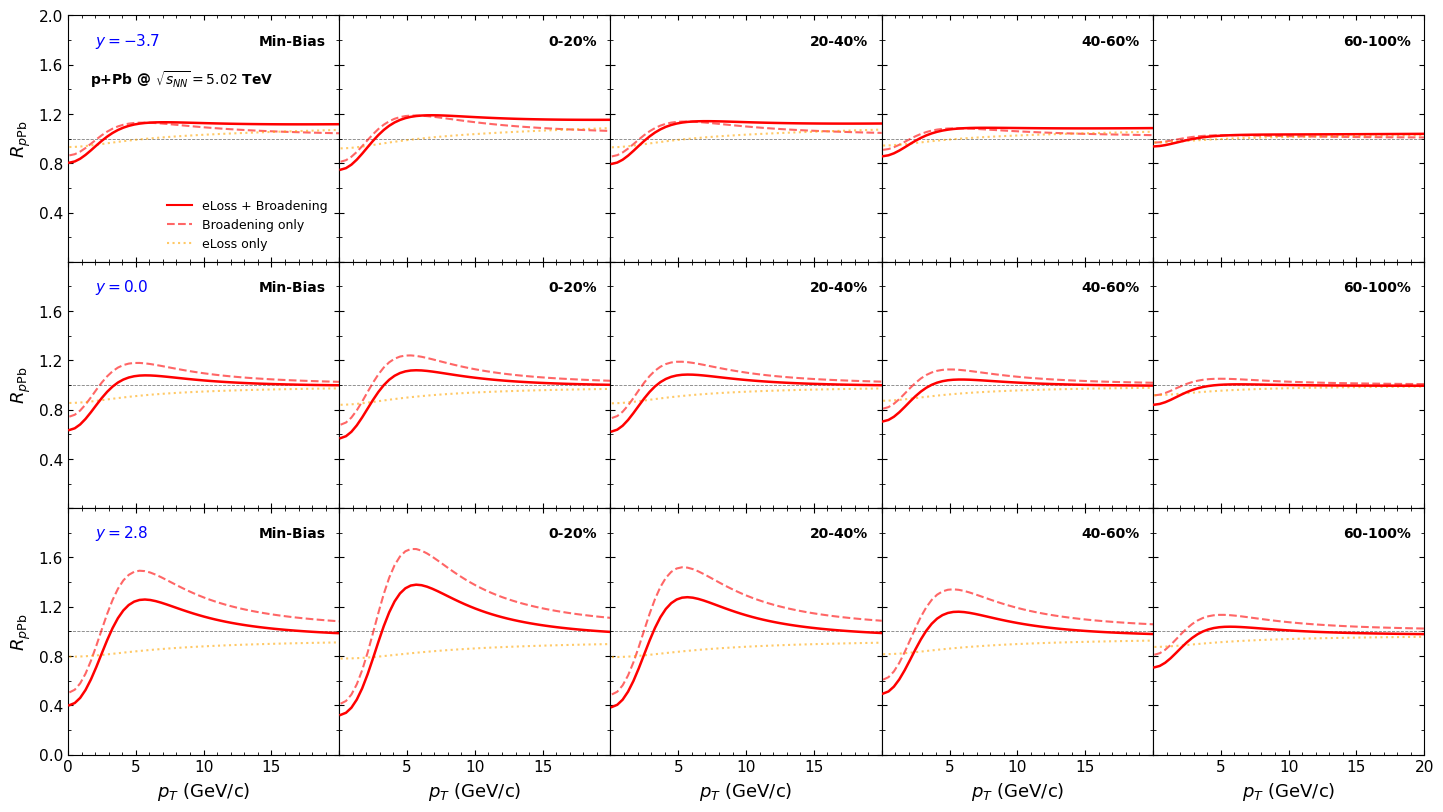

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator

def plot_master_rpa_grid(P, roots_GeV, qp_base_mb, qp_base_cent, gl, y_list, pT_arr):
    """
    Creates the publication grid with fixes for overlapping labels and line styling.
    """
    cent_tags = ["Min-Bias"] + cent_labels
    nrows = len(y_list)
    ncols = len(cent_tags)
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3.2*nrows), 
                            sharex=True, sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})

    for i, y_val in enumerate(y_list):
        for j, tag in enumerate(cent_tags):
            ax = axs[i, j]
            
            # --- Setup Parameters ---
            if tag == "Min-Bias":
                L_eff = gl.leff_minbias_pA()
                qp_task = replace(qp_base_mb, LA_fm=float(L_eff), LB_fm=float(L_eff))
            else:
                L_eff = Leff_dict_cent[tag]
                qp_task = replace(qp_base_cent, LA_fm=float(L_eff), LB_fm=float(L_eff))
            
            # --- Calculation ---
            rl_list, rb_list = [], []
            for pt in pT_arr:
                rl = R_pA_eloss(P, roots_GeV, qp_task, y_val, pt, Ny=96)
                rb = R_pA_broad(P, roots_GeV, qp_task, y_val, pt, Nphi=128)
                rl_list.append(rl)
                rb_list.append(rb)
            
            rl_array = np.array(rl_list)
            rb_array = np.array(rb_list)
            rt_list = rl_array * rb_array

            # --- Plotting ---
            # Total result
            ax.plot(pT_arr, rt_list, color='red', lw=1.8, label='eLoss + Broadening', zorder=5)
            # Broadening only (slightly lighter and thinner)
            ax.plot(pT_arr, rb_array, color='red', lw=1.5, ls='--', label='Broadening only', alpha=0.6, zorder=4)
            # eLoss only (optional: dotted/dash-dot)
            ax.plot(pT_arr, rl_array, color='orange', lw=1.5, ls=':', label='eLoss only', alpha=0.6, zorder=4)
            
            # --- Styling & Ticks ---
            ax.axhline(1.0, color="gray", lw=0.6, ls="--", zorder=1)
            ax.set_xlim(0, 20)
            ax.set_ylim(0, 2.0)
            
            # Y-axis: Use MaxNLocator to prevent too many ticks (set to ~4-5 intervals)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))
            
            # Minor Ticks (Reduced density)
            ax.xaxis.set_minor_locator(AutoMinorLocator(5))
            ax.yaxis.set_minor_locator(AutoMinorLocator(2))
            ax.tick_params(direction="in", which='both', top=True, right=True, labelsize=11)

            # --- Fix Overlapping Labels (X & Y) ---
            # X-axis Pruning (bottom row only)
            if i == nrows - 1:
                # Remove '0' label from columns 1 onwards to prevent overlap with previous panel's '20'
                if j > 0:
                    ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
                # Remove '20' label from columns 0 to N-1 to prevent overlap with next panel's '0'
                if j < ncols - 1:
                    ax.xaxis.get_major_ticks()[-1].label1.set_visible(False)

            # Y-axis Pruning (left column only)
            if j == 0:
                # Remove top label of lower panels to prevent overlap with panel above
                if i > 0:
                    ax.yaxis.get_major_ticks()[-1].label1.set_visible(False)
                # Remove bottom label of upper panels to prevent overlap with panel below
                if i < nrows - 1:
                    ax.yaxis.get_major_ticks()[0].label1.set_visible(False)

            # --- Annotations ---
            if j == 0:
                ax.text(0.1, 0.88, rf"$y = {y_val:.1f}$", transform=ax.transAxes, 
                        color='blue', fontweight='bold', fontsize=11)
            
            ax.text(0.95, 0.88, tag, transform=ax.transAxes, ha='right', 
                    fontweight='bold', fontsize=10)
            
            if i == nrows - 1:
                ax.set_xlabel(r"$p_T$ (GeV/c)", fontsize=13)
            if j == 0:
                ax.set_ylabel(r"$R_{p\mathrm{Pb}}$", fontsize=13)
            
            if j == 0 and i == 0:
                ax.text(0.08, 0.72, r"p+Pb @ $\sqrt{s_{NN}}=5.02$ TeV", 
                        transform=ax.transAxes, fontsize=10, fontweight='bold')
        
    # Legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=1.5, label='eLoss + Broadening'),
        Line2D([0], [0], color='red', lw=1.5, ls='--', alpha=0.6, label='Broadening only'),
        Line2D([0], [0], color='orange', lw=1.5, ls=':', alpha=0.6, label='eLoss only')
    ]
    axs[0, 0].legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=9)

    return fig

# --- Execute ---
y_targets = [-3.7, 0.0, 2.8] # Based on your previous setup
pT_eval = np.linspace(0.1, 20.0, 51)

master_fig = plot_master_rpa_grid(
    P=P_charmonia, 
    roots_GeV=roots5, 
    qp_base_mb=QP5_base_mb, 
    qp_base_cent=QP5_base, 
    gl=gl5, 
    y_list=y_targets, 
    pT_arr=pT_eval
)

master_fig.savefig("Charmonia_eloss_pTBroad_vs_pT_Grid_RpPb5TeV.pdf", dpi=300, bbox_inches='tight')
plt.show()

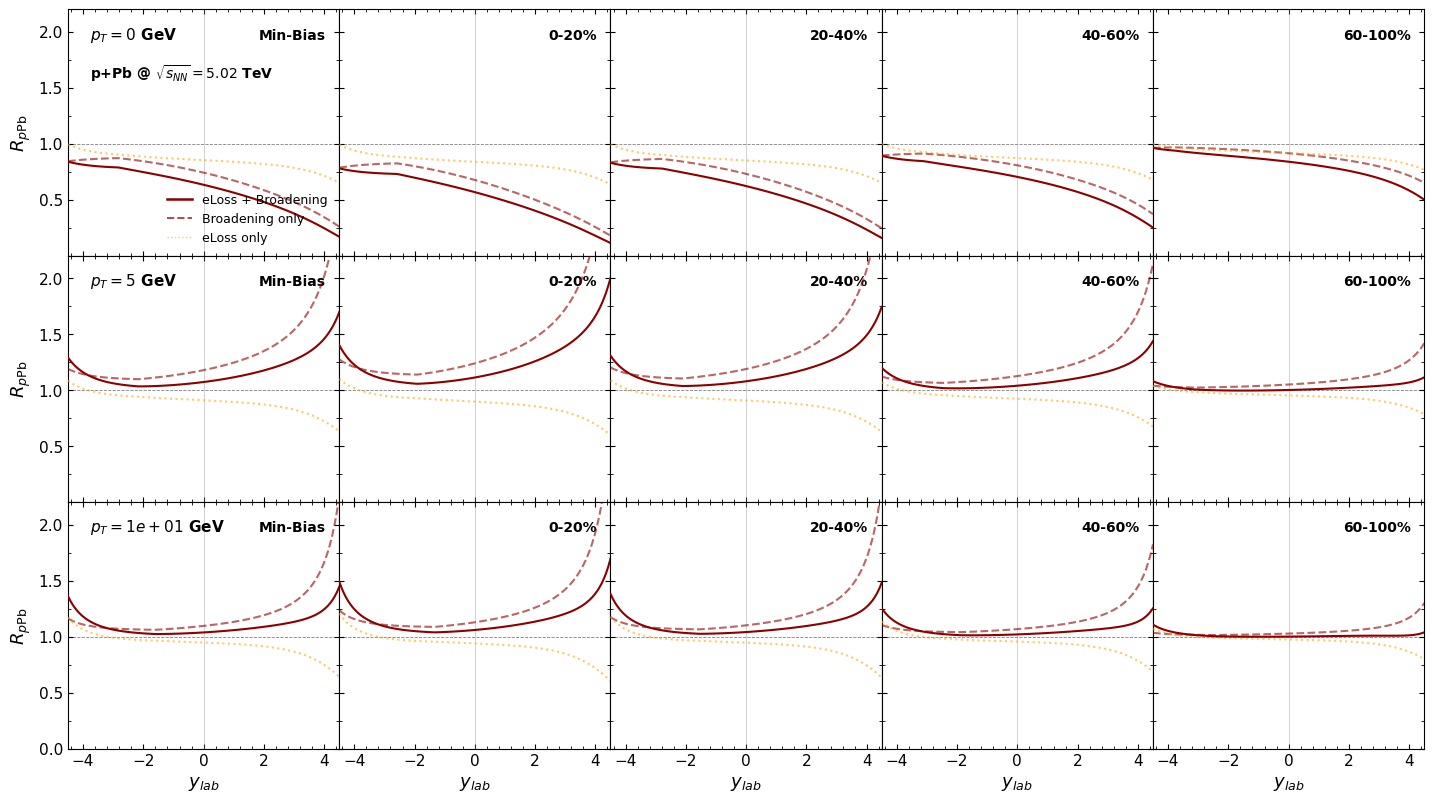

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator

def plot_master_rpa_vs_y_grid(P, roots_GeV, qp_base_mb, qp_base_cent, gl, pT_list, y_arr):
    """
    Consolidated grid for y-plots with aesthetic refinements:
    - Internal legend
    - Pruned overlapping labels on X and Y axes
    - Minor ticks on all sides (direction='in')
    - Softer line styling
    """
    cent_tags = ["Min-Bias"] + cent_labels
    nrows = len(pT_list)
    ncols = len(cent_tags)
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3.2*nrows), 
                            sharex=True, sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})

    for i, pt_val in enumerate(pT_list):
        for j, tag in enumerate(cent_tags):
            ax = axs[i, j]
            
            # --- Parameters ---
            if tag == "Min-Bias":
                L_eff = gl.leff_minbias_pA()
                qp_task = replace(qp_base_mb, LA_fm=float(L_eff), LB_fm=float(L_eff))
            else:
                L_eff = Leff_dict_cent[tag]
                qp_task = replace(qp_base_cent, LA_fm=float(L_eff), LB_fm=float(L_eff))
            
            # --- Calculation ---
            rl_list, rb_list = [], []
            for y in y_arr:
                rl = R_pA_eloss(P, roots_GeV, qp_task, y, pt_val, Ny=128)
                rb = R_pA_broad(P, roots_GeV, qp_task, y, pt_val, Nphi=128)
                rl_list.append(rl)
                rb_list.append(rb)
            
            rl_array = np.array(rl_list)
            rb_array = np.array(rb_list)
            rt_array = rl_array * rb_array

            # --- Plotting ---
            # Total (Thick solid)
            ax.plot(y_arr, rt_array, color='darkred', lw=1.5, label='eLoss + Broadening', zorder=5)
            # Broadening only (Thinner dashed, slightly transparent)
            ax.plot(y_arr, rb_array, color='darkred', lw=1.5, ls='--', label='Broadening only', alpha=0.6, zorder=4)
            # eLoss only (Light dotted)
            ax.plot(y_arr, rl_array, color='orange', lw=1.5, ls=':', label='eLoss only', alpha=0.6, zorder=4)
            
            # --- Styling ---
            ax.axhline(1.0, color="gray", lw=0.6, ls="--", zorder=1)
            ax.axvline(0.0, color="gray", lw=0.5, ls="-", alpha=0.5) 
            ax.set_xlim(y_arr.min(), y_arr.max())
            ax.set_ylim(0, 2.2)
            
            # Ticks and Density
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))
            ax.xaxis.set_minor_locator(AutoMinorLocator(5))
            ax.yaxis.set_minor_locator(AutoMinorLocator(2))
            ax.tick_params(direction="in", which='both', top=True, right=True, labelsize=11)

            # --- Fix Overlapping Labels (X & Y) ---
            # Prune X-axis (bottom row)
            if i == nrows - 1:
                if j > 0: # Hide 'left' edge label (except first col)
                    ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
                if j < ncols - 1: # Hide 'right' edge label (except last col)
                    ax.xaxis.get_major_ticks()[-1].label1.set_visible(False)

            # Prune Y-axis (left column)
            if j == 0:
                if i > 0: # Hide 'top' edge label (except first row)
                    ax.yaxis.get_major_ticks()[-1].label1.set_visible(False)
                if i < nrows - 1: # Hide 'bottom' edge label (except last row)
                    ax.yaxis.get_major_ticks()[0].label1.set_visible(False)

            # --- Annotations ---
            if j == 0:
                ax.text(0.08, 0.88, rf"$p_T = {pt_val:.1g}$ GeV", transform=ax.transAxes, 
                        color='black', fontweight='bold', fontsize=11)
                if i == 0:
                    ax.text(0.08, 0.72, rf"p+Pb @ $\sqrt{{s_{{NN}}}}={roots_GeV/1000:.2f}$ TeV", 
                            transform=ax.transAxes, fontsize=10, fontweight='bold')
            
            ax.text(0.95, 0.88, tag, transform=ax.transAxes, ha='right', 
                    fontweight='bold', fontsize=10)
            
            if i == nrows - 1:
                ax.set_xlabel(r"$y_{lab}$", fontsize=13)
            if j == 0:
                ax.set_ylabel(r"$R_{p\mathrm{Pb}}$", fontsize=13)

    # --- Internal Legend ---
    legend_elements = [
        Line2D([0], [0], color='darkred', lw=1.8, label='eLoss + Broadening'),
        Line2D([0], [0], color='darkred', lw=1.4, ls='--', alpha=0.7, label='Broadening only'),
        Line2D([0], [0], color='orange', lw=1.0, ls=':', alpha=0.6, label='eLoss only')
    ]
    # Place inside the first panel
    axs[0, 0].legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=9)

    return fig

# --- Run ---
pT_targets = [0.0, 5.0, 10.0]
y_eval = np.linspace(-4.5, 4.5, 120)

master_y_fig = plot_master_rpa_vs_y_grid(
    P=P_charmonia, 
    roots_GeV=roots5, 
    qp_base_mb=QP5_base_mb, 
    qp_base_cent=QP5_base, 
    gl=gl5, 
    pT_list=pT_targets, 
    y_arr=y_eval
)

master_y_fig.savefig("Charmonia_eloss_pTBroad_vs_y_Grid_RpPb5TeV.pdf", dpi=300, bbox_inches='tight')
plt.show()